In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install audiomentations

In [3]:
import os
import matplotlib.pyplot as plt

directories = {
    'Bonafide': '/content/drive/MyDrive/ASV_Dataset/Bonafide',
    'Spoof-A01': '/content/drive/MyDrive/ASV_Dataset/Spoof/A01',
    'Spoof-A02': '/content/drive/MyDrive/ASV_Dataset/Spoof/A02',
    'Spoof-A03': '/content/drive/MyDrive/ASV_Dataset/Spoof/A03',
    'Spoof-A04': '/content/drive/MyDrive/ASV_Dataset/Spoof/A04',
    'Spoof-A05': '/content/drive/MyDrive/ASV_Dataset/Spoof/A05',
    'Spoof-A06': '/content/drive/MyDrive/ASV_Dataset/Spoof/A06',
}

**Augmentation Pipeline**

In [4]:
import os
import numpy as np
from tqdm import tqdm
import librosa
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

# Defining audio augmentation pipeline
audio_augmentations = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(min_shift=-0.5, max_shift=0.5, p=0.5),
])

def augment_audio(y, sr):
    augmented_y = audio_augmentations(samples=y, sample_rate=sr)
    print("Augmentations applied.")
    return augmented_y


# Converting audio to Mel spectrogram
def audio_to_mel_spectrogram(file_path, sr=11000, n_mels=256, max_time_frames=256, apply_augmentation=True):

    try:
        y, original_sr = librosa.load(file_path, sr=sr)

        if apply_augmentation:
            y = augment_audio(y, sr)
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

        if mel_spectrogram.shape[1] > max_time_frames:
            mel_spectrogram = mel_spectrogram[:, :max_time_frames]
        else:
            pad_width = max_time_frames - mel_spectrogram.shape[1]
            mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, pad_width)), mode='constant')

        return mel_spectrogram
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return None

def load_data_from_folders(folders, labels, sr=11000, n_mels=256, max_time_frames=256, apply_augmentation=True):

    X, y = [], []
    for folder, label in zip(folders, labels):
        print(f"Processing {folder}...")
        files = os.listdir(folder)

        for file in tqdm(files):
            file_path = os.path.join(folder, file)
            mel_spectrogram = audio_to_mel_spectrogram(
                file_path, sr, n_mels, max_time_frames, apply_augmentation
            )
            if mel_spectrogram is not None:
                X.append(mel_spectrogram)
                y.append(label)
    return np.array(X), np.array(y)

bonafide_folder = '/content/drive/MyDrive/ASV_Dataset/Bonafide'
spoof_base_folder = '/content/drive/MyDrive/ASV_Dataset/Spoof'
spoof_classes = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06']

folders = [bonafide_folder] + [
    os.path.join(spoof_base_folder, spoof_class) for spoof_class in spoof_classes
]
labels = [0] + [i + 1 for i in range(len(spoof_classes))]

X, y = load_data_from_folders(folders, labels)

print(f"Loaded {len(X)} samples.")
print(f"Shape of feature data: {X.shape}, Shape of labels: {y.shape}")

Processing /content/drive/MyDrive/ASV_Dataset/Bonafide...


  0%|          | 0/2580 [00:00<?, ?it/s]

Augmentations applied.


  0%|          | 2/2580 [00:14<4:24:48,  6.16s/it] 

Augmentations applied.


...

Augmentations applied.
Augmentations applied.
Augmentations applied.
Augmentations applied.


100%|█████████▉| 3798/3800 [04:24<00:00, 17.28it/s]

Augmentations applied.
Augmentations applied.
Augmentations applied.


100%|██████████| 3800/3800 [04:25<00:00, 14.34it/s]


Augmentations applied.
Loaded 25380 samples.
Shape of feature data: (25380, 256, 256), Shape of labels: (25380,)


**Train Test Split**

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
X_normalized = np.array([scaler.fit_transform(img) for img in X])

X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

# Reshaping for CNN input
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Final input shape (for CNN): {X_train.shape}, {X_val.shape}, {X_test.shape}")

Training set shape: (17766, 256, 256), (17766,)
Validation set shape: (3807, 256, 256), (3807,)
Test set shape: (3807, 256, 256), (3807,)
Final input shape (for CNN): (17766, 256, 256, 1), (3807, 256, 256, 1), (3807, 256, 256, 1)


**Simple CNN**

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_stronger_cnn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # CNN Layers
    x = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = GlobalAveragePooling2D()(x)

    # Fully Connected Layers
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

input_shape = (256, 256, 1)
num_classes = 7

model = build_stronger_cnn_model(input_shape, num_classes)

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,949,447 (7.44 MB)

 Trainable params: 1,947,527 (7.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 74s 172ms/step - accuracy: 0.5015 - loss: 12.7960 - val_accuracy: 0.1497 - val_loss: 17.6056 - learning_rate: 1.0000e-04
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.7366 - loss: 7.8720 - val_accuracy: 0.1497 - val_loss: 21.4966 - learning_rate: 1.0000e-04
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.8288 - loss: 5.1678 - val_accuracy: 0.2574 - val_loss: 9.6985 - learning_rate: 1.0000e-04
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.8723 - loss: 3.5499 - val_accuracy: 0.6183 - val_loss: 3.7163 - learning_rate: 1.0000e-04
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9036 - loss: 2.5227 - val_accuracy: 0.2711 - val_loss: 5.6663 - learning_rate: 1.0000e-04
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9186 - loss: 1.8752 - val_accuracy: 0.8329 - val_loss: 1.8666 - learning_rate: 1.0000e-04
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms

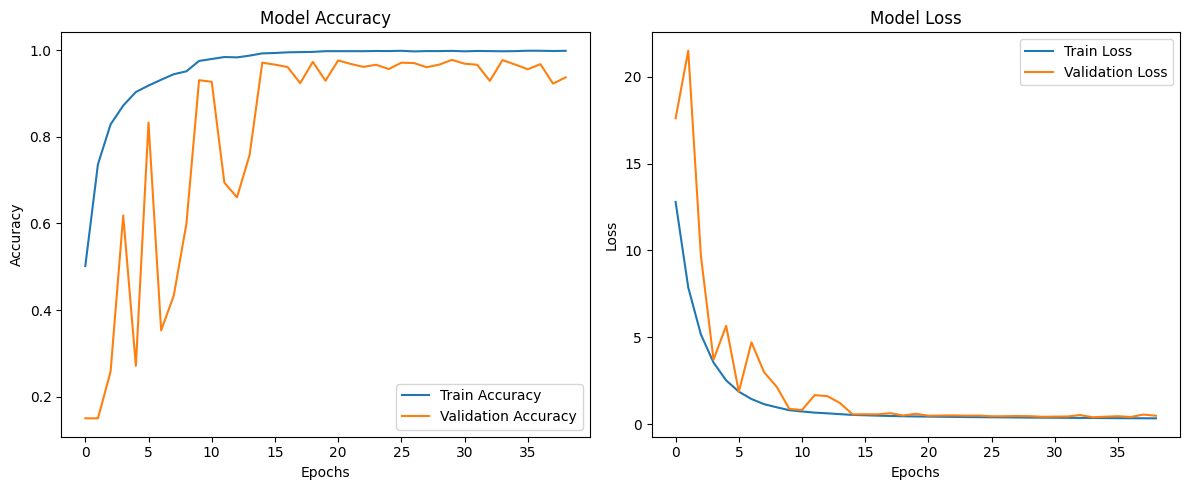

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=0.00001)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping, lr_reduction]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

119/119 - 1s - 8ms/step - accuracy: 0.9824 - loss: 0.2705
Test Loss: 0.2705
Test Accuracy: 0.9824
Final Accuracy of the model: 98.24%
119/119 - 4s - 34ms/step
Sample Predictions:
True Labels: [1 6 0 2 0 5 1 6 1 4]
Predicted Labels: [1 6 0 2 0 5 1 6 1 4]


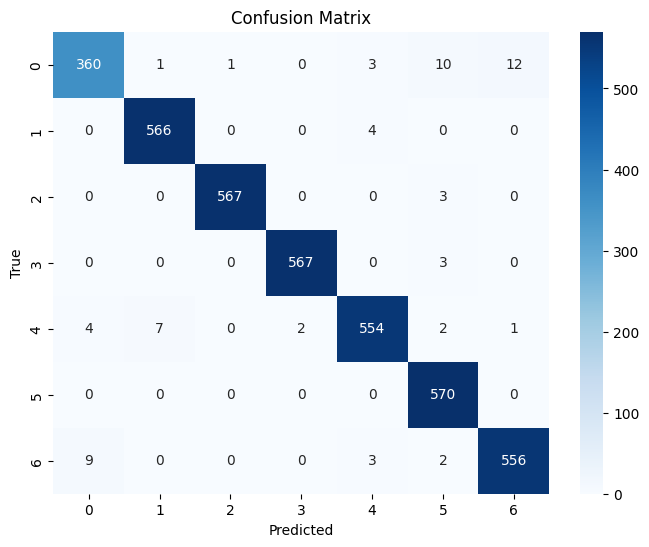

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Final Accuracy of the model: {test_accuracy * 100:.2f}%")

predictions = model.predict(X_test, verbose=2)
predicted_classes = predictions.argmax(axis=1)

true_classes = y_test
print("Sample Predictions:")
print(f"True Labels: {true_classes[:10]}")
print(f"Predicted Labels: {predicted_classes[:10]}")

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [8]:
model.save('/content/drive/MyDrive/deepfake_detector.keras')
print("Model saved!")

Model saved!


In [9]:
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/scaler.pkl')
print("Scaler saved!")

Scaler saved!


**EfficientNet**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.regularizers import l2


In [ ]:
def build_efficientnet_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(
        filters=3,
        kernel_size=(3, 3),
        padding="same",
        activation="linear",
        name="channel_adapter"
    )(inputs)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(512, activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model

In [ ]:
input_shape = (256, 256, 1)
num_classes = 7

model = build_efficientnet_model(input_shape, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter (Conv2D)        │ (None, 256, 256, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,843,720 (18.48 MB)

 Trainable params: 791,589 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 139s 297ms/step - accuracy: 0.1483 - loss: 2.2395 - val_accuracy: 0.1502 - val_loss: 2.0508 - learning_rate: 1.0000e-04
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1493 - loss: 2.1155 - val_accuracy: 0.1495 - val_loss: 2.0495 - learning_rate: 1.0000e-04
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1437 - loss: 2.0859 - val_accuracy: 0.1636 - val_loss: 2.0474 - learning_rate: 1.0000e-04
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1497 - loss: 2.0761 - val_accuracy: 0.1497 - val_loss: 2.0476 - learning_rate: 1.0000e-04
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1473 - loss: 2.0729 - val_accuracy: 0.1489 - val_loss: 2.0467 - learning_rate: 1.0000e-04
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1491 - loss: 2.0625 - val_accuracy: 0.1531 - val_loss: 2.0467 - learning_rate: 1.0000e-04
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/s

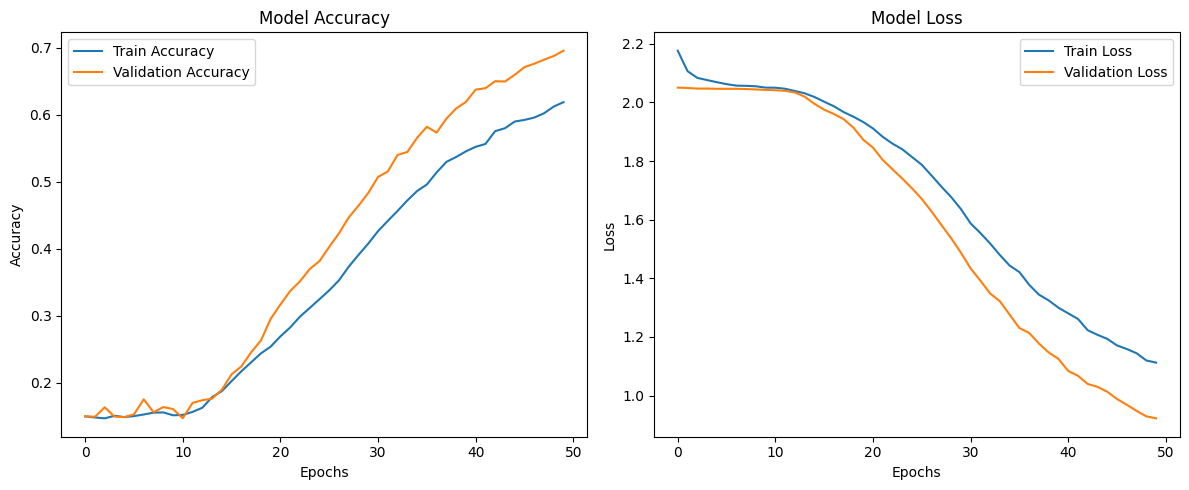

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=0.00001)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping, lr_reduction]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

119/119 - 1s - 12ms/step - accuracy: 0.6921 - loss: 0.9392
Test Loss: 0.9392
Test Accuracy: 0.6921
Final Accuracy of the model: 69.21%
119/119 - 16s - 133ms/step
Sample Predictions:
True Labels: [1 6 0 2 0 5 1 6 1 4]
Predicted Labels: [1 6 6 2 5 5 6 6 1 4]


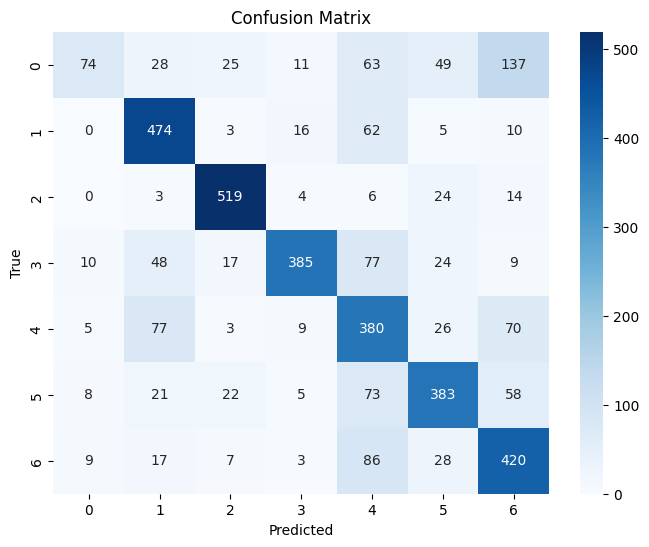

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Final Accuracy of the model: {test_accuracy * 100:.2f}%")

predictions = model.predict(X_test, verbose=2)
predicted_classes = predictions.argmax(axis=1)

true_classes = y_test
print("Sample Predictions:")
print(f"True Labels: {true_classes[:10]}")
print(f"Predicted Labels: {predicted_classes[:10]}")

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**DenseNet**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.regularizers import l2
def build_densenet121_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(
        filters=3,
        kernel_size=(3, 3),
        padding="same",
        activation="linear",
        name="channel_adapter"
    )(inputs)

    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(512, activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model
input_shape = (256, 256, 1)
num_classes = 7

model = build_densenet121_model(input_shape, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_adapter (Conv2D)        │ (None, 256, 256, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,699,557 (29.37 MB)

 Trainable params: 660,005 (2.52 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 133s 300ms/step - accuracy: 0.2821 - loss: 2.0711 - val_accuracy: 0.6165 - val_loss: 1.3321 - learning_rate: 1.0000e-04
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.5542 - loss: 1.2753 - val_accuracy: 0.7197 - val_loss: 0.9138 - learning_rate: 1.0000e-04
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.6464 - loss: 1.0551 - val_accuracy: 0.7581 - val_loss: 0.7609 - learning_rate: 1.0000e-04
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.6914 - loss: 0.9191 - val_accuracy: 0.7799 - val_loss: 0.6898 - learning_rate: 1.0000e-04
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.7213 - loss: 0.8306 - val_accuracy: 0.7991 - val_loss: 0.6325 - learning_rate: 1.0000e-04
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.7490 - loss: 0.7650 - val_accuracy: 0.8103 - val_loss: 0.5955 - learning_rate: 1.0000e-04
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/s

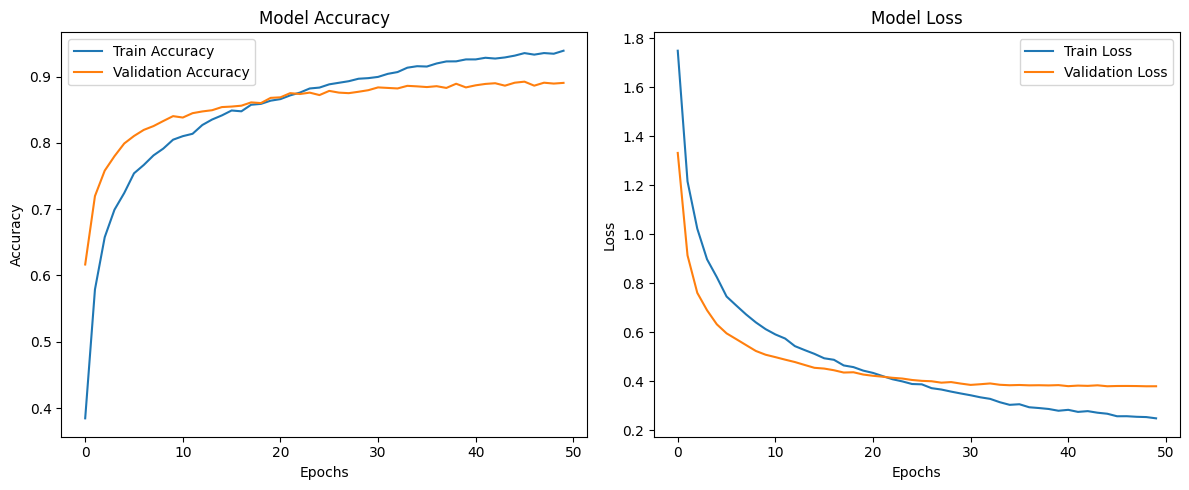

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=0.00001)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping, lr_reduction]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

119/119 - 2s - 20ms/step - accuracy: 0.8844 - loss: 0.4031
Test Loss: 0.4031
Test Accuracy: 0.8844
Final Accuracy of the model: 88.44%
119/119 - 26s - 217ms/step
Sample Predictions:
True Labels: [1 6 0 2 0 5 1 6 1 4]
Predicted Labels: [1 6 0 2 4 5 1 6 1 1]


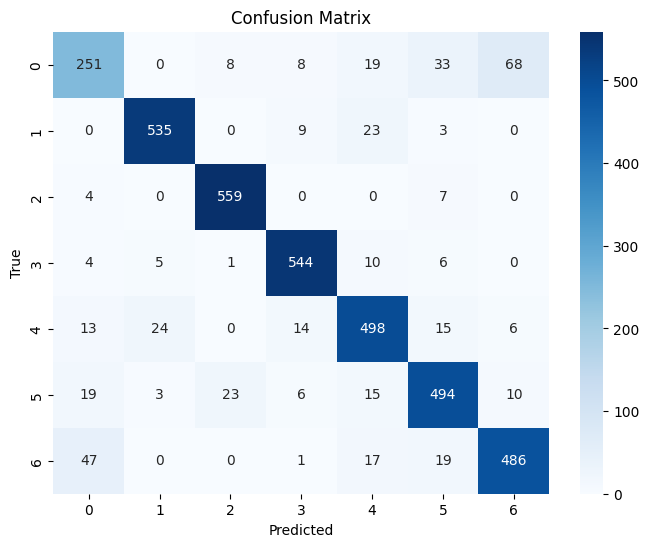

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Final Accuracy of the model: {test_accuracy * 100:.2f}%")

predictions = model.predict(X_test, verbose=2)
predicted_classes = predictions.argmax(axis=1)

true_classes = y_test
print("Sample Predictions:")
print(f"True Labels: {true_classes[:10]}")
print(f"Predicted Labels: {predicted_classes[:10]}")

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**CNN LSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Reshape,
    LSTM,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_stronger_cnn_lstm_model_v2(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Reshape((x.shape[1], -1))(x)

    x = LSTM(512, return_sequences=True, dropout=0.3)(x)
    x = LSTM(256, dropout=0.3)(x)

    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


input_shape = (256, 256, 1)
num_classes = 7

model = build_stronger_cnn_lstm_model_v2(input_shape, num_classes)

model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 8192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16, 512)        │    17,827,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,433,671 (77.95 MB)

 Trainable params: 20,431,751 (77.94 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=0.00001)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=50,
    verbose=1,
    callbacks=[early_stopping, lr_reduction]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Epoch 1/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 210s 355ms/step - accuracy: 0.2330 - loss: 12.5290 - val_accuracy: 0.1500 - val_loss: 9.4716 - learning_rate: 1.0000e-04
Epoch 2/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 194s 349ms/step - accuracy: 0.4547 - loss: 6.1944 - val_accuracy: 0.3142 - val_loss: 4.6631 - learning_rate: 1.0000e-04
Epoch 3/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 194s 349ms/step - accuracy: 0.6784 - loss: 3.3945 - val_accuracy: 0.7520 - val_loss: 2.3518 - learning_rate: 1.0000e-04
Epoch 4/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 194s 349ms/step - accuracy: 0.7608 - loss: 2.1965 - val_accuracy: 0.6872 - val_loss: 2.0781 - learning_rate: 1.0000e-04
Epoch 5/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 194s 349ms/step - accuracy: 0.8209 - loss: 1.5651 - val_accuracy: 0.6906 - val_loss: 1.7661 - learning_rate: 1.0000e-04
Epoch 6/50
556/556 ━━━━━━━━━━━━━━━━━━━━ 194s 349ms/step - accuracy: 0.8513 - loss: 1.2198 - val_accuracy: 0.7365 - val_loss: 1.3872 - learning_rate: 1.0000e-04
Epoch 7/50
556/556 ━━━━━━━━━━━━━━━━━━━━

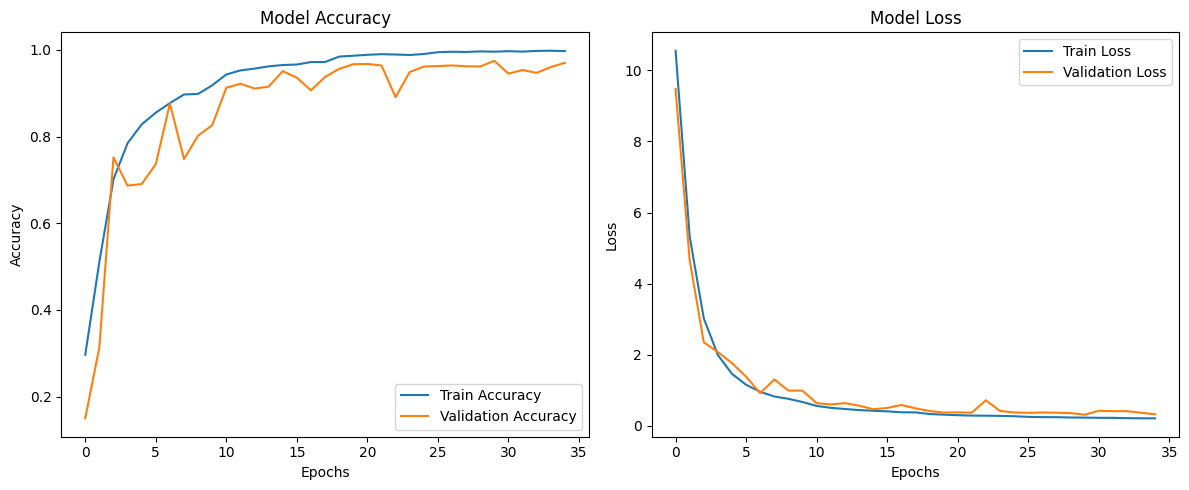

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()